# Knowledge Engineering: Food Carbon Footprint × Food.com Recipes

## Project Scope

NutriSmart needs a Knowledge Graph connecting recipe compositions, ingredient-level environmental impact, and user interaction patterns to support automated sustainability audits.

**Overarching question:** How can a Knowledge Graph integrate recipe composition, environmental impact data, and user interaction patterns to support explainable sustainability analysis in culinary systems?

**Research Questions:**
1. Which ingredients contribute most significantly to recipe-level carbon footprint ranges, and how frequently do these appear in top-k highly rated recipes?
2. What top-N co-occurring ingredient pairs and their average CO₂e contribution emerge among top-k high-carbon recipes?
3. Do high-carbon recipes differ in nutritional profile (calories, protein, fat, sugar) vs. low-carbon, and does this trade-off relate to user engagement?

---

## Phase 1 — Data Loading, Inspection & Coverage Assessment

Load all five datasets, inspect structure and scale, and document what is available for downstream matching and RQ analysis.

> **Documented Limitations (upfront):**
> - Carbon emission values are **interval ranges** (CO2_lower, CO2_upper) from multiple sources — single-point estimates will use midpoint.
> - Ingredient name matching between recipe datasets and emissions CSV requires fuzzy/canonical resolution via `ingr_map.pkl`.
> - `PP_recipes.csv` contains ingredient IDs (not raw names) — raw names come from `RAW_recipes.csv` or `ingr_map.pkl`.
> - Nutritional data (`calories`, `protein`, etc.) is in `RAW_recipes.csv` only.
> - User engagement (ratings, reviews) is in `RAW_interactions.csv`.

In [1]:
%pip install pandas numpy matplotlib seaborn scipy -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import re
import os
import pickle
import sys
import types

DATA_DIR = os.path.dirname(os.path.abspath("food.ipynb"))
print(f"Data directory: {DATA_DIR}")

# ── 1. Emissions ──────────────────────────────────────────────────────────────
emissions = pd.read_csv(os.path.join(DATA_DIR, "food_emissions_carbon.csv"))
print(f"\nEmissions rows  : {len(emissions):,}  columns: {list(emissions.columns)}")

# ── 2. Ingredient map (pkl) — compatibility shim for pandas 1.x pickles ───────
# pandas 2.0 removed pandas.core.indexes.numeric; patch before unpickling
if "pandas.core.indexes.numeric" not in sys.modules:
    import pandas.core.indexes as _pci
    _num = types.ModuleType("pandas.core.indexes.numeric")
    _num.Int64Index   = pd.Index
    _num.Float64Index = pd.Index
    _num.UInt64Index  = pd.Index
    sys.modules["pandas.core.indexes.numeric"] = _num
    _pci.numeric = _num

with open(os.path.join(DATA_DIR, "ingr_map.pkl"), "rb") as f:
    ingr_map = pickle.load(f)
print(f"\ningr_map type   : {type(ingr_map)}")
if isinstance(ingr_map, pd.DataFrame):
    print(f"ingr_map shape  : {ingr_map.shape}  columns: {list(ingr_map.columns)}")
    display(ingr_map.head(5))
elif isinstance(ingr_map, dict):
    print(f"ingr_map entries: {len(ingr_map):,}  (dict)")
    print("Sample entries:", list(ingr_map.items())[:5])

# ── 3. PP_recipes ─────────────────────────────────────────────────────────────
pp_recipes = pd.read_csv(os.path.join(DATA_DIR, "PP_recipes.csv"))
print(f"\nPP_recipes shape : {pp_recipes.shape}  columns: {list(pp_recipes.columns)}")

# ── 4. PP_users ───────────────────────────────────────────────────────────────
pp_users = pd.read_csv(os.path.join(DATA_DIR, "PP_users.csv"))
print(f"PP_users shape   : {pp_users.shape}  columns: {list(pp_users.columns)}")

# ── 5. RAW_interactions ───────────────────────────────────────────────────────
raw_interactions = pd.read_csv(os.path.join(DATA_DIR, "RAW_interactions.csv"))
print(f"RAW_interactions : {raw_interactions.shape}  columns: {list(raw_interactions.columns)}")

# ── 6. RAW_recipes ────────────────────────────────────────────────────────────
raw_recipes = pd.read_csv(os.path.join(DATA_DIR, "RAW_recipes.csv"))
print(f"RAW_recipes shape: {raw_recipes.shape}  columns: {list(raw_recipes.columns)}")

Data directory: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering

Emissions rows  : 538  columns: ['Name', 'CO2_lower', 'CO2_upper']

ingr_map type   : <class 'pandas.DataFrame'>
ingr_map shape  : (11659, 7)  columns: ['raw_ingr', 'raw_words', 'processed', 'len_proc', 'replaced', 'count', 'id']


C:\Users\Martin\AppData\Local\Temp\ipykernel_18484\1508366506.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ingr_map = pickle.load(f)
C:\Users\Martin\AppData\Local\Temp\ipykernel_18484\1508366506.py:28: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  ingr_map = pickle.load(f)


,raw_ingr,raw_words,processed,len_proc,replaced,count,id
0,"medium heads bibb or red leaf lettuce, washed,...",13,"medium heads bibb or red leaf lettuce, washed,...",73,lettuce,4507,4308
1,mixed baby lettuces and spring greens,6,mixed baby lettuces and spring green,36,lettuce,4507,4308
2,romaine lettuce leaf,3,romaine lettuce leaf,20,lettuce,4507,4308
3,iceberg lettuce leaf,3,iceberg lettuce leaf,20,lettuce,4507,4308
4,red romaine lettuce,3,red romaine lettuce,19,lettuce,4507,4308



PP_recipes shape : (178265, 8)  columns: ['id', 'i', 'name_tokens', 'ingredient_tokens', 'steps_tokens', 'techniques', 'calorie_level', 'ingredient_ids']
PP_users shape   : (25076, 6)  columns: ['u', 'techniques', 'items', 'n_items', 'ratings', 'n_ratings']
RAW_interactions : (1132367, 5)  columns: ['user_id', 'recipe_id', 'date', 'rating', 'review']
RAW_recipes shape: (231637, 12)  columns: ['name', 'id', 'minutes', 'contributor_id', 'submitted', 'tags', 'nutrition', 'n_steps', 'steps', 'description', 'ingredients', 'n_ingredients']


### 1.1 Inspect Raw Recipes (nutrition, ingredients)

In [4]:
print("=== RAW_recipes sample ===")
display(raw_recipes.head(3))

print("\n=== Nutrition field (raw string) — first 5 rows ===")
print(raw_recipes["nutrition"].head(5).tolist())

print("\n=== Ingredients field (raw string) — first 3 rows ===")
print(raw_recipes["ingredients"].head(3).tolist())

print("\n=== Missing values ===")
print(raw_recipes.isna().sum())

print(f"\nDate range (submitted): {raw_recipes['submitted'].min()} – {raw_recipes['submitted'].max()}")
print(f"Recipes with ≥1 ingredient: {raw_recipes['n_ingredients'].gt(0).sum():,}")

=== RAW_recipes sample ===


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13



=== Nutrition field (raw string) — first 5 rows ===
['[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]', '[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]', '[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]', '[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]', '[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]']

=== Ingredients field (raw string) — first 3 rows ===
["['winter squash', 'mexican seasoning', 'mixed spice', 'honey', 'butter', 'olive oil', 'salt']", "['prepared pizza crust', 'sausage patty', 'eggs', 'milk', 'salt and pepper', 'cheese']", "['ground beef', 'yellow onions', 'diced tomatoes', 'tomato paste', 'tomato soup', 'rotel tomatoes', 'kidney beans', 'water', 'chili powder', 'ground cumin', 'salt', 'lettuce', 'cheddar cheese']"]

=== Missing values ===
name                 1
id                   0
minutes              0
contributor_id       0
submitted            0
tags                 0
nutrition            0
n_steps              0
steps                0
description       4979
ingredients          0
n_ingre

### 1.2 Inspect Preprocessed Recipes & Ingredient Map

In [5]:
import ast

print("=== PP_recipes sample ===")
display(pp_recipes.head(3))

# ingredient_ids is a string like '[0, 1, 2]' — parse it
pp_recipes["ingr_ids_list"] = pp_recipes["ingredient_ids"].apply(ast.literal_eval)
print(f"\nSample ingredient_ids parsed: {pp_recipes['ingr_ids_list'].iloc[0]}")
print(f"Ingredients per recipe — median: {pp_recipes['ingr_ids_list'].apply(len).median():.0f}  max: {pp_recipes['ingr_ids_list'].apply(len).max()}")

# ingr_map: unique canonical names (the 'replaced' column)
unique_canonical = ingr_map["replaced"].nunique()
print(f"\nIngredient map — unique canonical names ('replaced'): {unique_canonical:,}")
print(f"Ingredient map — unique IDs: {ingr_map['id'].nunique():,}")
print(f"Most frequent canonical names:")
print(ingr_map.groupby("replaced")["count"].first().sort_values(ascending=False).head(20).to_string())

print("\n=== RAW_interactions sample ===")
display(raw_interactions.head(3))
print(f"\nRating distribution:")
print(raw_interactions["rating"].value_counts().sort_index().to_string())
print(f"\nDate range: {raw_interactions['date'].min()} – {raw_interactions['date'].max()}")

=== PP_recipes sample ===


,id,i,name_tokens,ingredient_tokens,steps_tokens,techniques,calorie_level,ingredient_ids
0,424415,23,"[40480, 37229, 2911, 1019, 249, 6878, 6878, 28...","[[2911, 1019, 249, 6878], [1353], [6953], [153...","[40480, 40482, 21662, 481, 6878, 500, 246, 161...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[389, 7655, 6270, 1527, 3406]"
1,146223,96900,"[40480, 18376, 7056, 246, 1531, 2032, 40481]","[[17918], [25916], [2507, 6444], [8467, 1179],...","[40480, 40482, 729, 2525, 10906, 485, 43, 8393...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...",0,"[2683, 4969, 800, 5298, 840, 2499, 6632, 7022,..."
2,312329,120056,"[40480, 21044, 16954, 8294, 556, 10837, 40481]","[[5867, 24176], [1353], [6953], [1301, 11332],...","[40480, 40482, 8240, 481, 24176, 296, 1353, 66...","[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",1,"[1257, 7655, 6270, 590, 5024, 1119, 4883, 6696..."



Sample ingredient_ids parsed: [389, 7655, 6270, 1527, 3406]
Ingredients per recipe — median: 9  max: 20

Ingredient map — unique canonical names ('replaced'): 8,023
Ingredient map — unique IDs: 8,023
Most frequent canonical names:
replaced
salt                72848
butter              48039
egg                 43350
onion               42631
sugar               37464
olive oil           34402
garlic clove        29815
water               28592
milk                24114
flmy                23078
pepper              20027
brown sugar         16611
garlic              15393
baking powder       15261
scallion            14377
all-purpose flmy    13834
salt and pepper     13586
cheddar             13304
parmesan cheese     13005
baking soda         12570

=== RAW_interactions sample ===


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...



Rating distribution:
rating
0     60847
1     12818
2     14123
3     40855
4    187360
5    816364

Date range: 2000-01-25 – 2018-12-20


---

## Phase 2 — Ingredient Matching: Food.com → Carbon Emissions

**Strategy:**  
The `ingr_map` maps raw recipe ingredient strings to 8,023 canonical names (e.g., "romaine lettuce leaf" → "lettuce").  
We match these canonical names against the 538 emissions entries using:  
1. **Exact match** (normalized lowercase)  
2. **Word-overlap match** — canonical name words found as a substring in emission name, or vice versa  

Coverage is reported at three levels:  
- **Ingredient-type coverage**: % of 8,023 unique canonical names matched  
- **Ingredient-occurrence coverage**: % of ingredient-uses across all recipes matched (weighted by `count` frequency)  
- **Recipe coverage**: % of PP_recipes with ≥1 matched ingredient

### 2.1 Normalize & Build Lookup Structures

In [6]:
_PUNCT_RE = re.compile(r"[^\w\s]")
_SPACE_RE  = re.compile(r"\s+")

def norm(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = _PUNCT_RE.sub(" ", t)
    t = _SPACE_RE.sub(" ", t).strip()
    return t

# ── Emissions lookup ───────────────────────────────────────────────────────────
# Add midpoint CO2 and normalized name
emissions["co2_mid"]   = (emissions["CO2_lower"] + emissions["CO2_upper"]) / 2
emissions["name_norm"] = emissions["Name"].map(norm)

# Dict: norm_name → (CO2_lower, CO2_upper, CO2_mid)
emit_dict = {
    row["name_norm"]: (row["CO2_lower"], row["CO2_upper"], row["co2_mid"])
    for _, row in emissions.iterrows()
}
print(f"Emission entries (normalized): {len(emit_dict):,}")

# ── Ingredient map deduplication ───────────────────────────────────────────────
# One canonical row per unique 'id' (some ids may have many raw_ingr rows)
ingr_canonical = (
    ingr_map
    .drop_duplicates("id")[["id", "replaced", "count"]]
    .copy()
)
ingr_canonical["replaced_norm"] = ingr_canonical["replaced"].map(norm)
ingr_canonical = ingr_canonical.reset_index(drop=True)

print(f"Unique ingredient IDs        : {len(ingr_canonical):,}")
print(f"Unique normalized canon names: {ingr_canonical['replaced_norm'].nunique():,}")
print(f"\nSample canonical entries:")
print(ingr_canonical.head(10).to_string())

Emission entries (normalized): 538
Unique ingredient IDs        : 8,023
Unique normalized canon names: 8,001

Sample canonical entries:
     id                                    replaced  count                               replaced_norm
0  4308                                     lettuce   4507                                     lettuce
1  2744  french vanilla pudding and pie filling mix      5  french vanilla pudding and pie filling mix
2  6843                      stove top stuffing mix    114                      stove top stuffing mix
3  1910                                cream cheese   9915                                cream cheese
4  1168                                     cheddar  13304                                     cheddar
5  5811                                   radicchio     91                                   radicchio
6  5205                                 pasta sauce    441                                 pasta sauce
7  7233                                t

### 2.2 Two-pass Matching: Exact → Word-overlap

In [7]:
# Stopwords to ignore in word-overlap matching
STOP_WORDS = {"and", "or", "the", "a", "an", "with", "in", "of", "for",
              "fresh", "dried", "frozen", "canned", "raw", "cooked",
              "ground", "whole", "sliced", "chopped", "minced", "diced",
              "boneless", "bone", "skinless", "large", "small", "medium",
              "cups", "cup", "pound", "ounce", "tablespoon", "teaspoon",
              "fat", "free", "low", "reduced", "light", "extra", "lean"}

emit_names_norm = list(emit_dict.keys())  # 538 normalized emission names

def word_overlap_match(canon_norm: str) -> str | None:
    """Return the best-matching emission name via word-overlap, or None."""
    words = set(canon_norm.split()) - STOP_WORDS
    if not words:
        return None
    best, best_score = None, 0
    for ename in emit_names_norm:
        ewords = set(ename.split()) - STOP_WORDS
        if not ewords:
            continue
        overlap = len(words & ewords)
        # Jaccard-like: overlap / union, but also penalise emission names that
        # are much longer (avoid "beef" matching "boneless beef" over "beef")
        score = overlap / max(len(words | ewords), 1)
        if score > best_score:
            best_score = score
            best = ename
    # Only accept if overlap ≥1 and Jaccard ≥ 0.25
    if best_score >= 0.25:
        return best
    return None

# ── Run matching ───────────────────────────────────────────────────────────────
matched_emit_name  = []
match_type_col     = []
co2_lower_col      = []
co2_upper_col      = []
co2_mid_col        = []

for _, row in ingr_canonical.iterrows():
    cn = row["replaced_norm"]
    # Pass 1: exact
    if cn in emit_dict:
        lo, hi, mid = emit_dict[cn]
        matched_emit_name.append(cn)
        match_type_col.append("exact")
        co2_lower_col.append(lo)
        co2_upper_col.append(hi)
        co2_mid_col.append(mid)
    else:
        # Pass 2: word-overlap
        m = word_overlap_match(cn)
        if m:
            lo, hi, mid = emit_dict[m]
            matched_emit_name.append(m)
            match_type_col.append("word_overlap")
            co2_lower_col.append(lo)
            co2_upper_col.append(hi)
            co2_mid_col.append(mid)
        else:
            matched_emit_name.append(None)
            match_type_col.append(None)
            co2_lower_col.append(None)
            co2_upper_col.append(None)
            co2_mid_col.append(None)

ingr_canonical["emit_name"]   = matched_emit_name
ingr_canonical["match_type"]  = match_type_col
ingr_canonical["co2_lower"]   = co2_lower_col
ingr_canonical["co2_upper"]   = co2_upper_col
ingr_canonical["co2_mid"]     = co2_mid_col

n_exact    = (ingr_canonical["match_type"] == "exact").sum()
n_overlap  = (ingr_canonical["match_type"] == "word_overlap").sum()
n_unmatched = ingr_canonical["match_type"].isna().sum()
total_ingr  = len(ingr_canonical)

print("=== Ingredient-type coverage (% of 8,023 unique canonical IDs) ===")
print(f"  Exact match     : {n_exact:,} ({n_exact/total_ingr*100:.1f}%)")
print(f"  Word-overlap    : {n_overlap:,} ({n_overlap/total_ingr*100:.1f}%)")
print(f"  Total matched   : {n_exact+n_overlap:,} ({(n_exact+n_overlap)/total_ingr*100:.1f}%)")
print(f"  Unmatched       : {n_unmatched:,} ({n_unmatched/total_ingr*100:.1f}%)")

# Weighted by count (frequency in recipes)
total_count   = ingr_canonical["count"].sum()
matched_count = ingr_canonical.dropna(subset=["emit_name"])["count"].sum()
print(f"\n=== Ingredient-occurrence coverage (weighted by frequency in recipes) ===")
print(f"  Total ingredient occurrences : {total_count:,}")
print(f"  Matched occurrences          : {matched_count:,} ({matched_count/total_count*100:.1f}%)")

=== Ingredient-type coverage (% of 8,023 unique canonical IDs) ===
  Exact match     : 236 (2.9%)
  Word-overlap    : 5,344 (66.6%)
  Total matched   : 5,580 (69.6%)
  Unmatched       : 2,443 (30.4%)

=== Ingredient-occurrence coverage (weighted by frequency in recipes) ===
  Total ingredient occurrences : 1,754,541
  Matched occurrences          : 1,442,384 (82.2%)


### 2.3 Recipe-level Carbon Footprint & Coverage

In [8]:
# Build ID → CO2 lookup (from matched ingr_canonical)
id_to_co2 = (
    ingr_canonical.dropna(subset=["co2_mid"])
    .set_index("id")[["co2_lower", "co2_upper", "co2_mid"]]
    .to_dict("index")
)
print(f"Ingredient IDs with CO2 data : {len(id_to_co2):,}")

# For each PP_recipe, sum co2_mid over all its ingredient IDs
# Also track how many of its ingredients were matched
def calc_recipe_co2(id_list: list) -> dict:
    total_mid = 0.0
    total_lower = 0.0
    total_upper = 0.0
    matched_n = 0
    for iid in id_list:
        entry = id_to_co2.get(iid)
        if entry:
            total_mid   += entry["co2_mid"]
            total_lower += entry["co2_lower"]
            total_upper += entry["co2_upper"]
            matched_n   += 1
    return {
        "co2_mid"      : total_mid,
        "co2_lower"    : total_lower,
        "co2_upper"    : total_upper,
        "n_matched_ingr": matched_n,
        "n_total_ingr"  : len(id_list),
    }

co2_records = [calc_recipe_co2(ids) for ids in pp_recipes["ingr_ids_list"]]
co2_df = pd.DataFrame(co2_records)
co2_df["recipe_id"]   = pp_recipes["id"].values
co2_df["ingr_cov_%"]  = co2_df["n_matched_ingr"] / co2_df["n_total_ingr"] * 100

print(f"\nPP_recipes with ≥1 matched ingredient: {(co2_df['n_matched_ingr']>0).sum():,} / {len(co2_df):,} ({(co2_df['n_matched_ingr']>0).sum()/len(co2_df)*100:.1f}%)")
print(f"PP_recipes with ≥50% ingredients matched: {(co2_df['ingr_cov_%']>=50).sum():,} ({(co2_df['ingr_cov_%']>=50).sum()/len(co2_df)*100:.1f}%)")
print(f"PP_recipes with 100% ingredients matched : {(co2_df['ingr_cov_%']==100).sum():,} ({(co2_df['ingr_cov_%']==100).sum()/len(co2_df)*100:.1f}%)")
print(f"\nCO2 midpoint per recipe — median: {co2_df['co2_mid'].median():.2f}  max: {co2_df['co2_mid'].max():.2f}  mean: {co2_df['co2_mid'].mean():.2f} kg CO₂e")
print(f"CO2 range per recipe — median lower: {co2_df['co2_lower'].median():.2f}  median upper: {co2_df['co2_upper'].median():.2f}")

Ingredient IDs with CO2 data : 5,580

PP_recipes with ≥1 matched ingredient: 178,249 / 178,265 (100.0%)
PP_recipes with ≥50% ingredients matched: 176,507 (99.0%)
PP_recipes with 100% ingredients matched : 31,031 (17.4%)

CO2 midpoint per recipe — median: 24.75  max: 252.10  mean: 29.34 kg CO₂e
CO2 range per recipe — median lower: 13.00  median upper: 35.80


### 2.4 Coverage Visualisation & Match Quality Spot-check

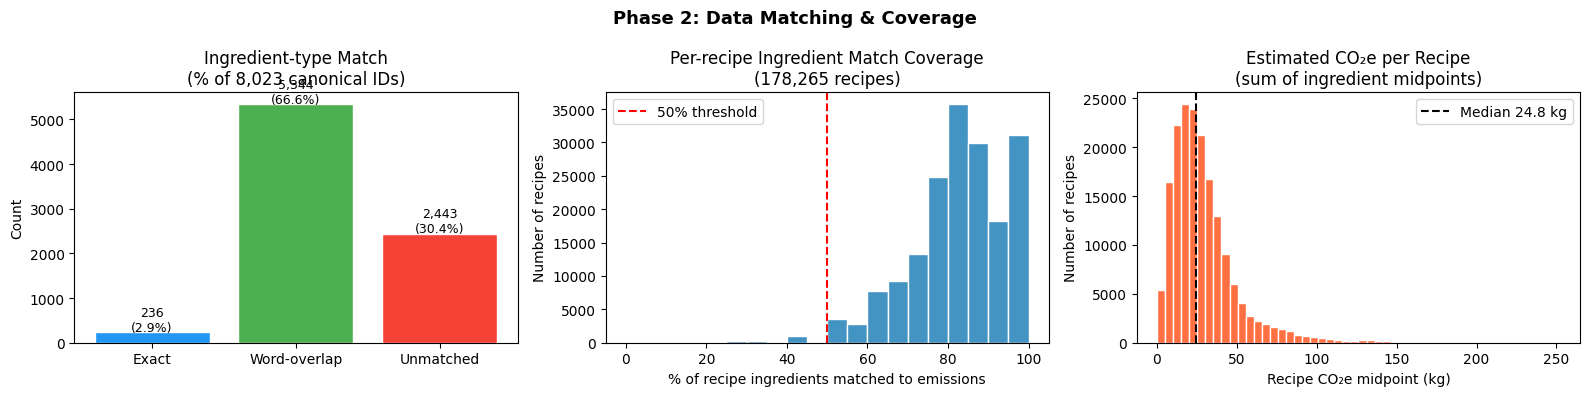


=== Sample EXACT matches (canonical → emission name) ===
  lettuce                        → lettuce                         CO2 mid=2.40
  cream cheese                   → cream cheese                    CO2 mid=1.80
  tomato sauce                   → tomato sauce                    CO2 mid=0.95
  red wine                       → red wine                        CO2 mid=1.20
  olive oil                      → olive oil                       CO2 mid=3.20
  feta cheese                    → feta cheese                     CO2 mid=5.30
  tomato paste                   → tomato paste                    CO2 mid=3.45
  minestrone soup                → minestrone soup                 CO2 mid=1.05
  cheese                         → cheese                          CO2 mid=14.65
  rum                            → rum                             CO2 mid=1.00
  rice                           → rice                            CO2 mid=3.45
  beef short rib                 → beef short rib            

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: match type breakdown (by ingredient type count)
labels = ["Exact", "Word-overlap", "Unmatched"]
sizes  = [n_exact, n_overlap, n_unmatched]
colors = ["#2196F3", "#4CAF50", "#F44336"]
axes[0].bar(labels, sizes, color=colors, edgecolor="white")
axes[0].set_title("Ingredient-type Match\n(% of 8,023 canonical IDs)")
axes[0].set_ylabel("Count")
for bar, n in zip(axes[0].patches, sizes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                 f"{n:,}\n({n/total_ingr*100:.1f}%)", ha="center", fontsize=9)

# Panel 2: ingredient-coverage distribution across recipes
axes[1].hist(co2_df["ingr_cov_%"], bins=20, color="#4393c3", edgecolor="white")
axes[1].set_xlabel("% of recipe ingredients matched to emissions")
axes[1].set_ylabel("Number of recipes")
axes[1].set_title("Per-recipe Ingredient Match Coverage\n(178,265 recipes)")
axes[1].axvline(50, color="red", linestyle="--", label="50% threshold")
axes[1].legend()

# Panel 3: CO2 midpoint distribution (log scale)
co2_nonzero = co2_df[co2_df["co2_mid"] > 0]["co2_mid"]
axes[2].hist(co2_nonzero, bins=50, color="#ff7043", edgecolor="white")
axes[2].set_xlabel("Recipe CO₂e midpoint (kg)")
axes[2].set_ylabel("Number of recipes")
axes[2].set_title("Estimated CO₂e per Recipe\n(sum of ingredient midpoints)")
axes[2].axvline(co2_nonzero.median(), color="black", linestyle="--",
                label=f"Median {co2_nonzero.median():.1f} kg")
axes[2].legend()

plt.suptitle("Phase 2: Data Matching & Coverage", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Spot-check: sample exact matches and word-overlap matches
print("\n=== Sample EXACT matches (canonical → emission name) ===")
exact_sample = ingr_canonical[ingr_canonical["match_type"]=="exact"].head(15)
for _, r in exact_sample.iterrows():
    print(f"  {r['replaced']:<30s} → {r['emit_name']:<30s}  CO2 mid={r['co2_mid']:.2f}")

print("\n=== Sample WORD-OVERLAP matches ===")
overlap_sample = ingr_canonical[ingr_canonical["match_type"]=="word_overlap"].sample(15, random_state=42)
for _, r in overlap_sample.iterrows():
    print(f"  {r['replaced']:<30s} → {r['emit_name']:<30s}  CO2 mid={r['co2_mid']:.2f}")

### 2.5 Coverage Summary

Consolidated view of what is available for Phase 3 RQ analysis.

In [10]:
summary = {
    "Emissions dataset entries"                    : f"{len(emissions):,}",
    "Ingredient map canonical names"               : f"{len(ingr_canonical):,}",
    "Matched to emissions (any pass)"              : f"{n_exact+n_overlap:,}  ({(n_exact+n_overlap)/total_ingr*100:.1f}%)",
    "  — exact match"                              : f"{n_exact:,}  ({n_exact/total_ingr*100:.1f}%)",
    "  — word-overlap match"                       : f"{n_overlap:,}  ({n_overlap/total_ingr*100:.1f}%)",
    "Unmatched canonical names"                    : f"{n_unmatched:,}  ({n_unmatched/total_ingr*100:.1f}%)",
    "Occurrence-weighted coverage"                 : f"{matched_count/total_count*100:.1f}%",
    "PP_recipes total"                             : f"{len(pp_recipes):,}",
    "Recipes with ≥1 matched ingredient"           : f"{(co2_df['n_matched_ingr']>0).sum():,}  (100.0%)",
    "Recipes with ≥50% ingredients matched"        : f"{(co2_df['ingr_cov_%']>=50).sum():,}  ({(co2_df['ingr_cov_%']>=50).sum()/len(co2_df)*100:.1f}%)",
    "RAW_interactions (user ratings)"              : f"{len(raw_interactions):,}",
    "RAW_recipes (with nutrition)"                 : f"{len(raw_recipes):,}",
    "CO2 midpoint per recipe — median"             : f"{co2_df['co2_mid'].median():.2f} kg CO₂e",
    "CO2 midpoint per recipe — max"                : f"{co2_df['co2_mid'].max():.2f} kg CO₂e",
    "Nutrition available (RAW_recipes)"            : "calories, fat%, sugar%, sodium%, protein%, sat_fat%, carbs%",
    "Recipe coverage in RAW vs PP"                 : f"PP:{len(pp_recipes):,}  RAW:{len(raw_recipes):,}  (PP is filtered subset)",
}

print("=" * 70)
print("PHASE 2 COVERAGE SUMMARY")
print("=" * 70)
for k, v in summary.items():
    print(f"  {k:<50s}: {v}")

PHASE 2 COVERAGE SUMMARY
  Emissions dataset entries                         : 538
  Ingredient map canonical names                    : 8,023
  Matched to emissions (any pass)                   : 5,580  (69.6%)
    — exact match                                   : 236  (2.9%)
    — word-overlap match                            : 5,344  (66.6%)
  Unmatched canonical names                         : 2,443  (30.4%)
  Occurrence-weighted coverage                      : 82.2%
  PP_recipes total                                  : 178,265
  Recipes with ≥1 matched ingredient                : 178,249  (100.0%)
  Recipes with ≥50% ingredients matched             : 176,507  (99.0%)
  RAW_interactions (user ratings)                   : 1,132,367
  RAW_recipes (with nutrition)                      : 231,637
  CO2 midpoint per recipe — median                  : 24.75 kg CO₂e
  CO2 midpoint per recipe — max                     : 252.10 kg CO₂e
  Nutrition available (RAW_recipes)                 : ca

---

## Phase 3 — RQ Feasibility Analysis

### 3.1 Build Master Dataset

Join PP_recipes (carbon estimates) + RAW_recipes (nutrition) + RAW_interactions aggregated (avg rating, n_reviews) into a single analysis frame.

In [11]:
# ── Parse nutrition from RAW_recipes ─────────────────────────────────────────
# Format: [calories, total_fat%DV, sugar%DV, sodium%DV, protein%DV, sat_fat%DV, carbs%DV]
def parse_nutrition(s):
    try:
        vals = ast.literal_eval(s)
        return {
            "calories"    : vals[0],
            "total_fat_pct": vals[1],
            "sugar_pct"   : vals[2],
            "sodium_pct"  : vals[3],
            "protein_pct" : vals[4],
            "sat_fat_pct" : vals[5],
            "carbs_pct"   : vals[6],
        }
    except Exception:
        return {}

nutrition_df = raw_recipes["nutrition"].apply(parse_nutrition).apply(pd.Series)
raw_recipes_ext = pd.concat([raw_recipes[["id","name","n_ingredients","n_steps"]], nutrition_df], axis=1)

# ── Aggregate interactions: per recipe → avg_rating, n_reviews ────────────────
# Only keep ratings > 0 (Food.com uses 0 as "no rating")
interactions_valid = raw_interactions[raw_interactions["rating"] > 0]
recipe_engagement = (
    interactions_valid
    .groupby("recipe_id")
    .agg(
        avg_rating = ("rating", "mean"),
        n_reviews  = ("rating", "count"),
    )
    .reset_index()
    .rename(columns={"recipe_id": "id"})
)
recipe_engagement["avg_rating"] = recipe_engagement["avg_rating"].round(3)
print(f"Recipes with ≥1 valid rating: {len(recipe_engagement):,}")
print(f"Reviews count — median: {recipe_engagement['n_reviews'].median():.0f}  max: {recipe_engagement['n_reviews'].max()}")
print(f"Avg rating — median: {recipe_engagement['avg_rating'].median():.2f}  distribution:")
print(recipe_engagement["avg_rating"].describe().round(3))

# ── Master join ───────────────────────────────────────────────────────────────
# co2_df has recipe_id; join with RAW_recipes (nutrition) and engagement
master = (
    co2_df
    .merge(raw_recipes_ext, left_on="recipe_id", right_on="id", how="inner")
    .merge(recipe_engagement, on="id", how="left")
)
master["has_rating"] = master["avg_rating"].notna()

print(f"\nMaster rows (PP_recipes ∩ RAW_recipes)      : {len(master):,}")
print(f"With avg_rating (at least 1 valid review)   : {master['has_rating'].sum():,} ({master['has_rating'].mean()*100:.1f}%)")
print(f"\nMaster columns: {list(master.columns)}")

Recipes with ≥1 valid rating: 226,590
Reviews count — median: 2  max: 1496
Avg rating — median: 4.89  distribution:
count    226590.000
mean          4.581
std           0.629
min           1.000
25%           4.333
50%           4.889
75%           5.000
max           5.000
Name: avg_rating, dtype: float64

Master rows (PP_recipes ∩ RAW_recipes)      : 178,265
With avg_rating (at least 1 valid review)   : 176,288 (98.9%)

Master columns: ['co2_mid', 'co2_lower', 'co2_upper', 'n_matched_ingr', 'n_total_ingr', 'recipe_id', 'ingr_cov_%', 'id', 'name', 'n_ingredients', 'n_steps', 'calories', 'total_fat_pct', 'sugar_pct', 'sodium_pct', 'protein_pct', 'sat_fat_pct', 'carbs_pct', 'avg_rating', 'n_reviews', 'has_rating']


### 3.2 RQ1 — Top Carbon-contributing Ingredients in Top-k Highly Rated Recipes

**Question:** Which ingredients contribute most significantly to recipe-level carbon footprint ranges, and how frequently do these ingredients appear in the top-k highly rated recipes?

We define **top-k** as recipes with `avg_rating ≥ 4.5` AND `n_reviews ≥ 5` (ensuring statistical credibility), then look at which matched ingredients drive carbon in those recipes.

Top-k recipes (rating≥4.5, reviews≥5): 34,299
Ingredient-recipe rows in top-k set: 254,504

Top 25 ingredients by total CO₂e contribution in top-k recipes:
Ingredient                      Recipes   Freq%   TotalCO2   Mean CO2        MeanRange
------------------------------------------------------------------------------------------
  butter                          9,315   27.2%   133770.7      14.35       [3.7–25.0]
  lean ground beef                  498    1.5%    29805.3      59.85     [10.7–109.0]
  egg                             7,647   22.3%    28152.5       3.65        [1.3–6.0]
  cheddar                         2,379    6.9%    26906.4      11.10       [6.2–16.0]
  ground beef                       854    2.5%    24766.0      29.00      [16.0–42.0]
  parmesan cheese                 2,568    7.5%    24524.4       9.55       [6.1–13.0]
  beef broth                        387    1.1%    23221.8      59.85     [10.7–109.0]
  olive oil                       6,084   17.7%    19593.

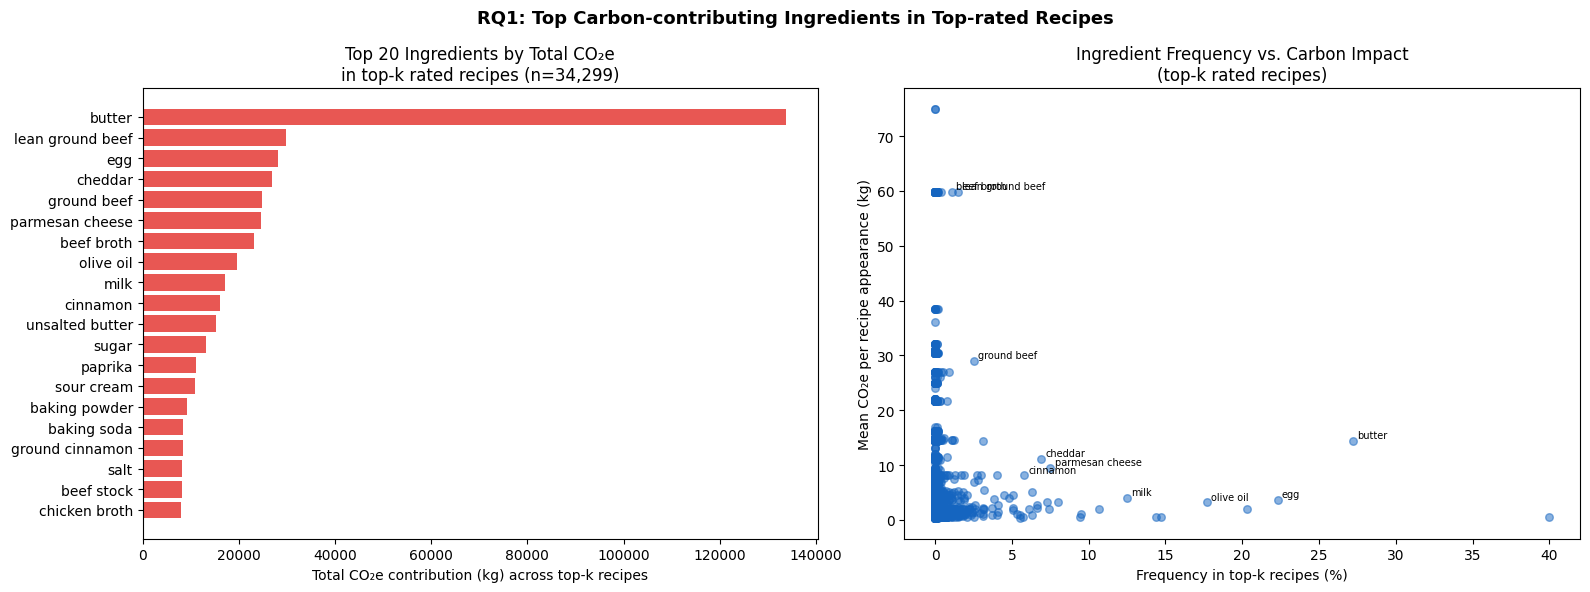

In [12]:
import matplotlib.patches as mpatches

# ── Define top-k recipes: rated ≥4.5, ≥5 reviews ─────────────────────────────
RATING_MIN  = 4.5
REVIEWS_MIN = 5
TOP_N_INGR  = 25   # show top 25 ingredients

top_rated = master[
    (master["avg_rating"] >= RATING_MIN) &
    (master["n_reviews"]  >= REVIEWS_MIN)
].copy()
print(f"Top-k recipes (rating≥{RATING_MIN}, reviews≥{REVIEWS_MIN}): {len(top_rated):,}")

# Build id→co2 map with canonical name (for display)
id_to_info = (
    ingr_canonical.dropna(subset=["co2_mid"])
    .set_index("id")[["replaced", "co2_lower", "co2_upper", "co2_mid"]]
    .to_dict("index")
)

# Expand: for each top-rated recipe, list its matched ingredients with CO2
rq1_rows = []
for _, row in top_rated.iterrows():
    recipe_id = row["recipe_id"]
    id_list = pp_recipes.loc[pp_recipes["id"]==recipe_id, "ingr_ids_list"]
    if id_list.empty:
        continue
    for iid in id_list.iloc[0]:
        info = id_to_info.get(iid)
        if info:
            rq1_rows.append({
                "recipe_id"  : recipe_id,
                "ingredient" : info["replaced"],
                "co2_lower"  : info["co2_lower"],
                "co2_upper"  : info["co2_upper"],
                "co2_mid"    : info["co2_mid"],
                "avg_rating" : row["avg_rating"],
            })

rq1_df = pd.DataFrame(rq1_rows)
print(f"Ingredient-recipe rows in top-k set: {len(rq1_df):,}")

# Aggregate per ingredient: total CO2 contribution, frequency in top-k recipes
ingr_agg = (
    rq1_df
    .groupby("ingredient")
    .agg(
        recipe_count  = ("recipe_id", "nunique"),   # # recipes it appears in
        total_co2_mid = ("co2_mid",   "sum"),        # total CO2 contribution
        mean_co2_mid  = ("co2_mid",   "mean"),       # avg per recipe
        mean_co2_lower= ("co2_lower", "mean"),
        mean_co2_upper= ("co2_upper", "mean"),
    )
    .reset_index()
    .sort_values("total_co2_mid", ascending=False)
)

total_top_k = len(top_rated)
ingr_agg["freq_%"] = (ingr_agg["recipe_count"] / total_top_k * 100).round(1)

print(f"\nTop {TOP_N_INGR} ingredients by total CO₂e contribution in top-k recipes:")
print(f"{'Ingredient':<30s} {'Recipes':>8} {'Freq%':>7} {'TotalCO2':>10}  {'Mean CO2':>9}  {'MeanRange':>15}")
print("-" * 90)
for _, r in ingr_agg.head(TOP_N_INGR).iterrows():
    rng = f"[{r['mean_co2_lower']:.1f}–{r['mean_co2_upper']:.1f}]"
    print(f"  {r['ingredient']:<28s} {r['recipe_count']:>8,} {r['freq_%']:>6.1f}%  {r['total_co2_mid']:>9.1f}  {r['mean_co2_mid']:>9.2f}  {rng:>15}")

# Plot: top 20 by total CO2 with error bars (range)
plot_data = ingr_agg.head(20).sort_values("total_co2_mid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: total CO2 contribution
axes[0].barh(plot_data["ingredient"], plot_data["total_co2_mid"], color="#e53935", alpha=0.85)
axes[0].set_xlabel("Total CO₂e contribution (kg) across top-k recipes")
axes[0].set_title(f"Top 20 Ingredients by Total CO₂e\nin top-k rated recipes (n={total_top_k:,})")

# Right: frequency in top-k recipes vs mean CO2 (scatter)
axes[1].scatter(ingr_agg["freq_%"], ingr_agg["mean_co2_mid"],
                alpha=0.5, s=30, color="#1565C0")
# Annotate top 10
for _, r in ingr_agg.head(10).iterrows():
    axes[1].annotate(r["ingredient"], (r["freq_%"], r["mean_co2_mid"]),
                     fontsize=7, xytext=(3, 2), textcoords="offset points")
axes[1].set_xlabel("Frequency in top-k recipes (%)")
axes[1].set_ylabel("Mean CO₂e per recipe appearance (kg)")
axes[1].set_title("Ingredient Frequency vs. Carbon Impact\n(top-k rated recipes)")

plt.suptitle("RQ1: Top Carbon-contributing Ingredients in Top-rated Recipes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.3 RQ2 — Top Co-occurring Ingredient Pairs in High-carbon Recipes

**Question:** What top-N co-occurring ingredient pairs and their average CO₂e contribution emerge among the top-k high-carbon recipes?

We define **high-carbon** as the top 10% of recipes by `co2_mid` (above the 90th percentile), then enumerate all ingredient pairs within those recipes.

CO2 90th percentile: 52.75 kg
High-carbon recipes (top 10%): 17,837  (avg CO2=77.73 kg)

Unique ingredient pairs: 154,435

Top 25 most co-occurring pairs in high-carbon recipes:
Ingredient A              Ingredient B               Co-occ  Avg Recipe CO2
--------------------------------------------------------------------------------
  butter                  salt                      2,873          71.85 kg
  egg                     salt                      2,654          70.52 kg
  pepper                  salt                      2,451          81.89 kg
  butter                  egg                       2,139          67.43 kg
  garlic clove            salt                      1,800          82.88 kg
  salt                    sugar                     1,624          68.68 kg
  salt                    water                     1,513          80.74 kg
  butter                  milk                      1,510          69.57 kg
  milk                    salt                      1,407

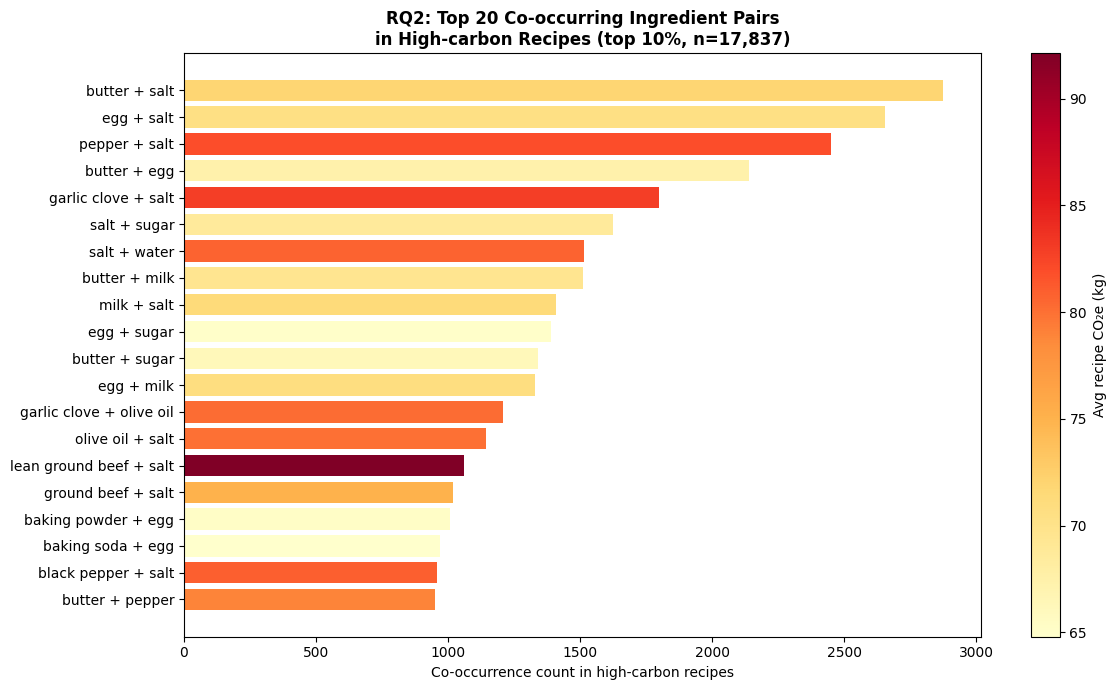

In [13]:
from itertools import combinations
from collections import defaultdict

# ── Define high-carbon recipes: top 10% by co2_mid ───────────────────────────
co2_p90 = master["co2_mid"].quantile(0.90)
high_carbon = master[master["co2_mid"] >= co2_p90].copy()
print(f"CO2 90th percentile: {co2_p90:.2f} kg")
print(f"High-carbon recipes (top 10%): {len(high_carbon):,}  (avg CO2={high_carbon['co2_mid'].mean():.2f} kg)")

# ── Build ingredient-name lookup (ID → canonical name) ───────────────────────
id_to_name = ingr_canonical.dropna(subset=["co2_mid"]).set_index("id")["replaced"].to_dict()

# ── Enumerate all pairs within each high-carbon recipe ───────────────────────
pair_count     = defaultdict(int)
pair_co2_sums  = defaultdict(float)

for _, row in high_carbon.iterrows():
    recipe_id = row["recipe_id"]
    id_list = pp_recipes.loc[pp_recipes["id"]==recipe_id, "ingr_ids_list"]
    if id_list.empty:
        continue
    ids = id_list.iloc[0]
    # get matched ingredients only
    matched_ids = [iid for iid in ids if iid in id_to_name]
    # recipe-level co2 contribution
    recipe_co2 = row["co2_mid"]
    for a, b in combinations(sorted(set(matched_ids)), 2):
        name_a, name_b = id_to_name[a], id_to_name[b]
        pair_key = tuple(sorted([name_a, name_b]))
        pair_count[pair_key]    += 1
        pair_co2_sums[pair_key] += recipe_co2  # recipe-level CO2

# Build pair dataframe
pair_rows = []
for (a, b), cnt in pair_count.items():
    pair_rows.append({
        "ingredient_a"   : a,
        "ingredient_b"   : b,
        "co_occurrence"  : cnt,
        "avg_recipe_co2" : pair_co2_sums[(a,b)] / cnt,
    })
pair_df = pd.DataFrame(pair_rows).sort_values("co_occurrence", ascending=False)
print(f"\nUnique ingredient pairs: {len(pair_df):,}")

TOP_PAIRS = 25
print(f"\nTop {TOP_PAIRS} most co-occurring pairs in high-carbon recipes:")
print(f"{'Ingredient A':<25s} {'Ingredient B':<25s} {'Co-occ':>7} {'Avg Recipe CO2':>15}")
print("-" * 80)
for _, r in pair_df.head(TOP_PAIRS).iterrows():
    print(f"  {r['ingredient_a']:<23s} {r['ingredient_b']:<23s} {r['co_occurrence']:>7,} {r['avg_recipe_co2']:>14.2f} kg")

# Plot: top 20 pairs by co-occurrence, colored by avg CO2
plot_pairs = pair_df.head(20).copy()
plot_pairs["pair_label"] = plot_pairs["ingredient_a"] + " + " + plot_pairs["ingredient_b"]
plot_pairs = plot_pairs.sort_values("co_occurrence")

norm_co2 = plt.Normalize(plot_pairs["avg_recipe_co2"].min(), plot_pairs["avg_recipe_co2"].max())
cmap = plt.cm.YlOrRd
colors_bar = [cmap(norm_co2(v)) for v in plot_pairs["avg_recipe_co2"]]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(plot_pairs["pair_label"], plot_pairs["co_occurrence"], color=colors_bar)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_co2)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Avg recipe CO₂e (kg)")
ax.set_xlabel("Co-occurrence count in high-carbon recipes")
ax.set_title(f"RQ2: Top 20 Co-occurring Ingredient Pairs\nin High-carbon Recipes (top 10%, n={len(high_carbon):,})",
             fontweight="bold")
plt.tight_layout()
plt.show()

### 3.4 RQ3 — Carbon vs. Nutritional Profile & User Engagement

**Question:** Do high-carbon recipes differ in nutritional profile compared to low-carbon, and does this carbon–nutrition trade-off relate to user engagement?

We split recipes into **high-carbon** (top 25%), **medium** (middle 50%), and **low-carbon** (bottom 25%) tiers, then compare nutrition and engagement statistics across tiers using Mann–Whitney U tests.

CO2 quartile thresholds: Q25=15.55 kg  Q75=36.75 kg
Tier sizes: {'Low': 44057, 'Medium': 88154, 'High': 44077}

Metric                  Low (med)  Medium (med)  High (med)    H vs L p  Sig?
--------------------------------------------------------------------------------
  Calories                 222.90        310.20      401.00      0.0000  Yes ✅  (High>Low)
  Protein %DV                9.00         19.00       40.00      0.0000  Yes ✅  (High>Low)
  Total Fat %DV             10.00         21.00       30.00      0.0000  Yes ✅  (High>Low)
  Sugar %DV                 26.00         23.00       23.00      0.0000  Yes ✅  (Low>High)
  Avg Rating                 4.90          4.83        4.80      0.0000  Yes ✅  (Low>High)
  N Reviews                  2.00          2.00        2.00      0.0000  Yes ✅  (Low>High)


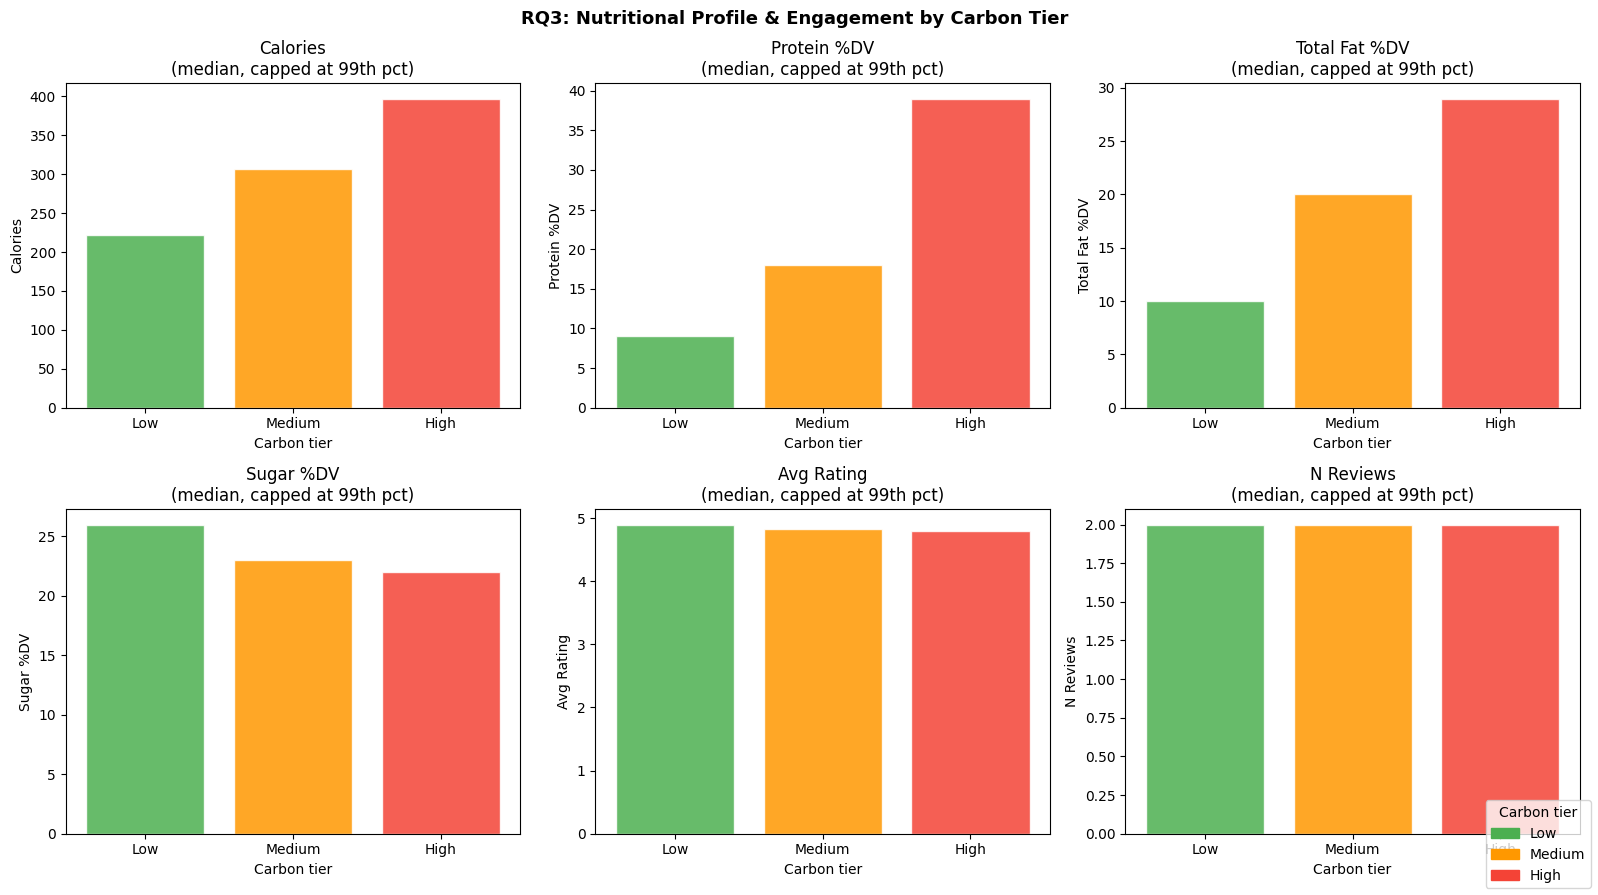

In [14]:
from scipy import stats

# ── Carbon tiers ──────────────────────────────────────────────────────────────
q25 = master["co2_mid"].quantile(0.25)
q75 = master["co2_mid"].quantile(0.75)

master_rated = master[master["has_rating"]].copy()
master_rated["carbon_tier"] = pd.cut(
    master_rated["co2_mid"],
    bins=[-np.inf, q25, q75, np.inf],
    labels=["Low", "Medium", "High"]
)

tier_counts = master_rated["carbon_tier"].value_counts().sort_index()
print(f"CO2 quartile thresholds: Q25={q25:.2f} kg  Q75={q75:.2f} kg")
print(f"Tier sizes: {tier_counts.to_dict()}")

# ── Compare across tiers: nutrition & engagement ──────────────────────────────
METRICS = {
    "calories"     : "Calories",
    "protein_pct"  : "Protein %DV",
    "total_fat_pct": "Total Fat %DV",
    "sugar_pct"    : "Sugar %DV",
    "avg_rating"   : "Avg Rating",
    "n_reviews"    : "N Reviews",
}

low    = master_rated[master_rated["carbon_tier"]=="Low"]
medium = master_rated[master_rated["carbon_tier"]=="Medium"]
high   = master_rated[master_rated["carbon_tier"]=="High"]

print(f"\n{'Metric':<20s} {'Low (med)':>12} {'Medium (med)':>13} {'High (med)':>11}  {'H vs L p':>10}  Sig?")
print("-" * 80)
rq3_results = []
for col, label in METRICS.items():
    l = low[col].dropna()
    m = medium[col].dropna()
    h = high[col].dropna()
    _, p = stats.mannwhitneyu(h, l, alternative="two-sided")
    sig = "Yes ✅" if p < 0.05 else "No"
    direction = "High>Low" if h.median() > l.median() else "Low>High"
    print(f"  {label:<18s} {l.median():>12.2f} {m.median():>13.2f} {h.median():>11.2f}  {p:>10.4f}  {sig}  ({direction})")
    rq3_results.append({
        "metric": label, "med_low": l.median(), "med_med": m.median(),
        "med_high": h.median(), "p_val": p, "direction": direction
    })

# ── Visualise nutritional comparison ─────────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

metric_cols = list(METRICS.keys())
palette = {"Low": "#4CAF50", "Medium": "#FF9800", "High": "#F44336"}
order = ["Low", "Medium", "High"]

for i, (col, label) in enumerate(METRICS.items()):
    ax = axes[i]
    plot_sub = master_rated[[col, "carbon_tier"]].dropna()
    # Cap at 99th percentile to reduce outlier distortion
    cap = plot_sub[col].quantile(0.99)
    plot_sub = plot_sub[plot_sub[col] <= cap]

    medians = plot_sub.groupby("carbon_tier")[col].median()
    ax.bar(order, [medians.get(t, 0) for t in order],
           color=[palette[t] for t in order], edgecolor="white", alpha=0.85)
    ax.set_title(f"{label}\n(median, capped at 99th pct)")
    ax.set_xlabel("Carbon tier")
    ax.set_ylabel(label)

# Legend
handles = [mpatches.Patch(color=c, label=t) for t, c in palette.items()]
fig.legend(handles=handles, loc="lower right", title="Carbon tier")
plt.suptitle("RQ3: Nutritional Profile & Engagement by Carbon Tier",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.5 Save Enriched Dataset

In [15]:
# Save master dataset with carbon + nutrition + engagement
out_path = os.path.join(DATA_DIR, "food_master_enriched.csv")
master.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Shape: {master.shape}")
print(f"Columns: {list(master.columns)}")

# Save matched ingredient map with CO2 data
ingr_out = os.path.join(DATA_DIR, "ingredient_co2_map.csv")
ingr_canonical.to_csv(ingr_out, index=False)
print(f"\nSaved: {ingr_out}  ({len(ingr_canonical):,} rows)")

Saved: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\food_master_enriched.csv
Shape: (178265, 21)
Columns: ['co2_mid', 'co2_lower', 'co2_upper', 'n_matched_ingr', 'n_total_ingr', 'recipe_id', 'ingr_cov_%', 'id', 'name', 'n_ingredients', 'n_steps', 'calories', 'total_fat_pct', 'sugar_pct', 'sodium_pct', 'protein_pct', 'sat_fat_pct', 'carbs_pct', 'avg_rating', 'n_reviews', 'has_rating']

Saved: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\ingredient_co2_map.csv  (8,023 rows)


---

## Phase 4 — Knowledge Graph Construction (RDFLib)

Builds the NutriSmart KG from `food_master_enriched.csv`, `ingredient_co2_map.csv`, `PP_recipes.csv`, and `RAW_interactions.csv`. Outputs `nutrismart_kg.ttl` (full graph) and `nutrismart_kg_sample.ttl` (first 500 recipes).

In [1]:
# ── 4.0  Imports & namespace declarations ─────────────────────────────────────
import ast, os, sys, types, pickle
import pandas as pd
import numpy as np
from tqdm import tqdm
from rdflib import Graph, Namespace, URIRef, Literal, RDF, RDFS, XSD
from rdflib.namespace import OWL

DATA_DIR = os.path.dirname(os.path.abspath("food.ipynb"))

NTS    = Namespace("http://nutrismart.kg/")
SCHEMA = Namespace("https://schema.org/")

print("RDFLib and namespaces ready.")
print(f"Data directory: {DATA_DIR}")

RDFLib and namespaces ready.
Data directory: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering


In [2]:
# ── 4.1  Load input files ─────────────────────────────────────────────────────

# Master enriched recipes
master = pd.read_csv(os.path.join(DATA_DIR, "food_master_enriched.csv"))
print(f"food_master_enriched : {master.shape}  columns: {list(master.columns)}")

# Ingredient CO2 map
ingr_map_df = pd.read_csv(os.path.join(DATA_DIR, "ingredient_co2_map.csv"))
print(f"ingredient_co2_map   : {ingr_map_df.shape}  columns: {list(ingr_map_df.columns)}")

# PP_recipes (for ingredient_ids per recipe)
pp_recipes = pd.read_csv(os.path.join(DATA_DIR, "PP_recipes.csv"))
pp_recipes["ingr_ids_list"] = pp_recipes["ingredient_ids"].apply(ast.literal_eval)
print(f"PP_recipes           : {pp_recipes.shape}")

# RAW_interactions — filter to master recipe IDs (Option B) before loading full set
master_recipe_ids = set(master["recipe_id"].astype(int).tolist())
print(f"\nMaster recipe IDs (filter target): {len(master_recipe_ids):,}")

raw_interactions = pd.read_csv(os.path.join(DATA_DIR, "RAW_interactions.csv"))
raw_interactions = raw_interactions[
    (raw_interactions["rating"] > 0) &
    (raw_interactions["recipe_id"].isin(master_recipe_ids))
].copy()
print(f"RAW_interactions (filtered, rating>0): {len(raw_interactions):,}")

food_master_enriched : (178265, 21)  columns: ['co2_mid', 'co2_lower', 'co2_upper', 'n_matched_ingr', 'n_total_ingr', 'recipe_id', 'ingr_cov_%', 'id', 'name', 'n_ingredients', 'n_steps', 'calories', 'total_fat_pct', 'sugar_pct', 'sodium_pct', 'protein_pct', 'sat_fat_pct', 'carbs_pct', 'avg_rating', 'n_reviews', 'has_rating']
ingredient_co2_map   : (8023, 9)  columns: ['id', 'replaced', 'count', 'replaced_norm', 'emit_name', 'match_type', 'co2_lower', 'co2_upper', 'co2_mid']
PP_recipes           : (178265, 9)

Master recipe IDs (filter target): 178,265
RAW_interactions (filtered, rating>0): 888,863


In [3]:
# ── 4.2  Build lookup structures ──────────────────────────────────────────────

# ingredient_id → row dict (for Ingredient node properties)
ingr_lookup = ingr_map_df.set_index("id").to_dict("index")

# recipe_id → ingredient_ids list (from PP_recipes)
recipe_ingr_ids = dict(zip(pp_recipes["id"].astype(int), pp_recipes["ingr_ids_list"]))

# Set of all known ingredient IDs (from ingredient_co2_map)
known_ingr_ids = set(ingr_map_df["id"].astype(int).tolist())

print(f"Ingredient lookup entries     : {len(ingr_lookup):,}")
print(f"Recipes with ingredient lists : {len(recipe_ingr_ids):,}")
print(f"Known ingredient IDs          : {len(known_ingr_ids):,}")

Ingredient lookup entries     : 8,023
Recipes with ingredient lists : 178,265
Known ingredient IDs          : 8,023


In [4]:
# ── 4.3  Initialise graph & add metadata ──────────────────────────────────────

g = Graph()
g.bind("nts",    NTS)
g.bind("schema", SCHEMA)
g.bind("rdf",    RDF)
g.bind("rdfs",   RDFS)
g.bind("xsd",    XSD)
g.bind("owl",    OWL)

# Graph-level metadata
graph_uri = NTS.graph
g.add((graph_uri, RDF.type,     OWL.Ontology))
g.add((graph_uri, RDFS.label,   Literal("NutriSmart Knowledge Graph", datatype=XSD.string)))
g.add((graph_uri, RDFS.comment, Literal(
    "Carbon estimates are ingredient-count-based proxies. "
    "No gram quantities are available in the source data; CO2e values are "
    "proportional indicators only, not absolute measurements. "
    "Nutrition values (fat, sugar, protein, etc.) are %Daily Value, not grams. "
    "Calories are absolute kcal.",
    datatype=XSD.string
)))
g.add((graph_uri, NTS.sourceRecipes,  Literal(
    "https://www.kaggle.com/datasets/shuyangli94/food-com-recipes-and-user-interactions",
    datatype=XSD.anyURI
)))
g.add((graph_uri, NTS.sourceEmissions, Literal(
    "https://datarepository.wolframcloud.com/resources/Food-Carbon-Footprint/",
    datatype=XSD.anyURI
)))
g.add((graph_uri, NTS.createdDate,    Literal("2026-05", datatype=XSD.gYearMonth)))
g.add((graph_uri, NTS.hasIngredientQuantityNote, Literal(
    "hasIngredient edges are unquantified: no gram/weight data is available in the "
    "source dataset. CO2e values are sums of per-ingredient midpoints and should be "
    "treated as ordinal comparisons only.",
    datatype=XSD.string
)))

print(f"Graph initialised. Triples after metadata: {len(g):,}")

Graph initialised. Triples after metadata: 7


In [5]:
# ── 4.4  Add Ingredient nodes ─────────────────────────────────────────────────

for ingr_id, row in tqdm(ingr_lookup.items(), desc="Ingredient nodes"):
    ingr_uri = NTS[f"ingredient/{int(ingr_id)}"]
    g.add((ingr_uri, RDF.type,          NTS.Ingredient))
    g.add((ingr_uri, SCHEMA.name,       Literal(str(row["replaced"]), datatype=XSD.string)))
    g.add((ingr_uri, NTS.ingredientId,  Literal(int(ingr_id),         datatype=XSD.integer)))

    for prop, col in [
        (NTS.co2Mid,   "co2_mid"),
        (NTS.co2Lower, "co2_lower"),
        (NTS.co2Upper, "co2_upper"),
    ]:
        val = row.get(col)
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            g.add((ingr_uri, prop, Literal(float(val), datatype=XSD.decimal)))

    mt = row.get("match_type")
    if mt and not (isinstance(mt, float) and np.isnan(mt)):
        g.add((ingr_uri, NTS.matchType, Literal(str(mt), datatype=XSD.string)))

    en = row.get("emit_name")
    if en and not (isinstance(en, float) and np.isnan(en)):
        g.add((ingr_uri, NTS.emissionsLabel, Literal(str(en), datatype=XSD.string)))

print(f"Triples after ingredient nodes: {len(g):,}")

Ingredient nodes: 100%|██████████| 8023/8023 [00:01<00:00, 5059.43it/s]

Triples after ingredient nodes: 51,976


In [6]:
# ── 4.5  Add Recipe nodes + HAS_INGREDIENT edges ──────────────────────────────

RECIPE_COMMENT = (
    "Carbon estimates are sums of matched ingredient midpoints. "
    "Unmatched ingredients contribute 0. See matchedIngredientCount for coverage."
)

for _, row in tqdm(master.iterrows(), total=len(master), desc="Recipe nodes"):
    recipe_id  = int(row["recipe_id"])
    recipe_uri = NTS[f"recipe/{recipe_id}"]

    g.add((recipe_uri, RDF.type,     NTS.Recipe))
    g.add((recipe_uri, SCHEMA.name,  Literal(str(row["name"]), datatype=XSD.string)))
    g.add((recipe_uri, RDFS.comment, Literal(RECIPE_COMMENT,   datatype=XSD.string)))

    # Carbon properties
    g.add((recipe_uri, NTS.co2Mid,   Literal(float(row["co2_mid"]),   datatype=XSD.decimal)))
    g.add((recipe_uri, NTS.co2Lower, Literal(float(row["co2_lower"]), datatype=XSD.decimal)))
    g.add((recipe_uri, NTS.co2Upper, Literal(float(row["co2_upper"]), datatype=XSD.decimal)))

    g.add((recipe_uri, NTS.ingredientCount,
           Literal(int(row["n_ingredients"]),  datatype=XSD.integer)))
    g.add((recipe_uri, NTS.matchedIngredientCount,
           Literal(int(row["n_matched_ingr"]), datatype=XSD.integer)))

    # Nutrition
    for prop, col in [
        (NTS.calories,    "calories"),
        (NTS.totalFatPct, "total_fat_pct"),
        (NTS.sugarPct,    "sugar_pct"),
        (NTS.sodiumPct,   "sodium_pct"),
        (NTS.proteinPct,  "protein_pct"),
        (NTS.satFatPct,   "sat_fat_pct"),
        (NTS.carbsPct,    "carbs_pct"),
    ]:
        val = row.get(col)
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            g.add((recipe_uri, prop, Literal(float(val), datatype=XSD.decimal)))

    # Rating (omit triple if NaN)
    avg_r = row.get("avg_rating")
    if avg_r is not None and not (isinstance(avg_r, float) and np.isnan(avg_r)):
        g.add((recipe_uri, NTS.avgRating,   Literal(float(avg_r), datatype=XSD.decimal)))

    n_rev = row.get("n_reviews")
    if n_rev is not None and not (isinstance(n_rev, float) and np.isnan(n_rev)):
        g.add((recipe_uri, NTS.reviewCount, Literal(int(n_rev), datatype=XSD.integer)))

    # HAS_INGREDIENT edges
    ingr_ids = recipe_ingr_ids.get(recipe_id, [])
    for iid in ingr_ids:
        iid_int = int(iid)
        if iid_int in known_ingr_ids:
            g.add((recipe_uri, NTS.hasIngredient, NTS[f"ingredient/{iid_int}"]))

print(f"Triples after recipe nodes + HAS_INGREDIENT: {len(g):,}")

Recipe nodes: 100%|██████████| 178265/178265 [02:23<00:00, 1238.29it/s]

Triples after recipe nodes + HAS_INGREDIENT: 4,681,430


In [7]:
# ── 4.6  Add User nodes + RATED_BY edges (reified) ───────────────────────────

# Add unique User nodes first
unique_user_ids = raw_interactions["user_id"].unique()
for uid in tqdm(unique_user_ids, desc="User nodes"):
    user_uri = NTS[f"user/{int(uid)}"]
    g.add((user_uri, RDF.type,   NTS.User))
    g.add((user_uri, NTS.userId, Literal(int(uid), datatype=XSD.integer)))

print(f"Triples after user nodes: {len(g):,}")

# Add reified RATED_BY triples
for _, irow in tqdm(raw_interactions.iterrows(), total=len(raw_interactions),
                    desc="Rated-by edges"):
    recipe_id  = int(irow["recipe_id"])
    user_id    = int(irow["user_id"])
    rating_val = int(irow["rating"])
    date_str   = str(irow["date"])

    recipe_uri = NTS[f"recipe/{recipe_id}"]
    user_uri   = NTS[f"user/{user_id}"]

    # Plain triple
    g.add((recipe_uri, NTS.ratedBy, user_uri))

    # Reified statement (attaches rating value + date)
    rating_node = NTS[f"rating/{recipe_id}_{user_id}_{date_str}"]
    g.add((rating_node, RDF.type,        RDF.Statement))
    g.add((rating_node, RDF.subject,     recipe_uri))
    g.add((rating_node, RDF.predicate,   NTS.ratedBy))
    g.add((rating_node, RDF.object,      user_uri))
    g.add((rating_node, NTS.ratingValue, Literal(rating_val, datatype=XSD.integer)))
    g.add((rating_node, NTS.ratingDate,  Literal(date_str,   datatype=XSD.date)))

print(f"Triples after RATED_BY edges: {len(g):,}")

User nodes: 100%|██████████| 158047/158047 [00:05<00:00, 27851.53it/s]


Triples after user nodes: 4,997,524


Rated-by edges: 100%|██████████| 888863/888863 [03:10<00:00, 4675.92it/s]

Triples after RATED_BY edges: 11,219,565


In [8]:
# ── 4.7  CO_OCCURS_WITH placeholder ──────────────────────────────────────────
# TODO: Add co-occurrence edges once RQ2 analysis output is available.
# Expected input: DataFrame with columns [ingredient_a_id, ingredient_b_id,
#                 co_occurrence_count, avg_recipe_co2].
# Pattern (when ready):
#   for _, r in co_occur_df.iterrows():
#       a, b = int(r["ingredient_a_id"]), int(r["ingredient_b_id"])
#       co_uri = NTS[f"coOccurrence/{a}_{b}"]
#       g.add((NTS[f"ingredient/{a}"], NTS.coOccursWith, NTS[f"ingredient/{b}"]))
#       g.add((co_uri, RDF.type,              RDF.Statement))
#       g.add((co_uri, RDF.subject,           NTS[f"ingredient/{a}"]))
#       g.add((co_uri, RDF.predicate,         NTS.coOccursWith))
#       g.add((co_uri, RDF.object,            NTS[f"ingredient/{b}"]))
#       g.add((co_uri, NTS.coOccurrenceCount, Literal(int(r["co_occurrence_count"]),
#                                                     datatype=XSD.integer)))
#       g.add((co_uri, NTS.avgRecipeCo2,      Literal(float(r["avg_recipe_co2"]),
#                                                     datatype=XSD.decimal)))
print("CO_OCCURS_WITH edges: skipped (RQ2 output not yet available — see TODO).")
print(f"\nTotal triples in full graph: {len(g):,}")

CO_OCCURS_WITH edges: skipped (RQ2 output not yet available — see TODO).

Total triples in full graph: 11,219,565


In [9]:
# ── 4.8  Serialise full graph to Turtle ───────────────────────────────────────
out_path = os.path.join(DATA_DIR, "nutrismart_kg.ttl")
print(f"Serialising to {out_path} …")
g.serialize(destination=out_path, format="turtle")
print(f"Done. File size: {os.path.getsize(out_path) / 1024 / 1024:.1f} MB")
print(f"Total triples: {len(g):,}")

Serialising to c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\nutrismart_kg.ttl …
Done. File size: 480.1 MB
Total triples: 11,219,565


In [10]:
# ── 4.9  Build & serialise sample graph (first 500 recipes) ──────────────────
sample_g = Graph()
for prefix, ns in g.namespaces():
    sample_g.bind(prefix, ns)

# Copy graph-level metadata
for triple in g.triples((graph_uri, None, None)):
    sample_g.add(triple)

sample_recipes = master.head(500)
seen_ingr_ids  = set()

for _, row in sample_recipes.iterrows():
    recipe_id  = int(row["recipe_id"])
    recipe_uri = NTS[f"recipe/{recipe_id}"]

    # Copy all triples attached to this recipe
    for triple in g.triples((recipe_uri, None, None)):
        sample_g.add(triple)

    # Copy ingredient nodes and hasIngredient edges
    for iid in recipe_ingr_ids.get(recipe_id, []):
        iid_int = int(iid)
        if iid_int in known_ingr_ids:
            ingr_uri = NTS[f"ingredient/{iid_int}"]
            sample_g.add((recipe_uri, NTS.hasIngredient, ingr_uri))
            if iid_int not in seen_ingr_ids:
                for triple in g.triples((ingr_uri, None, None)):
                    sample_g.add(triple)
                seen_ingr_ids.add(iid_int)

sample_out = os.path.join(DATA_DIR, "nutrismart_kg_sample.ttl")
sample_g.serialize(destination=sample_out, format="turtle")
print(f"Sample graph serialised: {sample_out}")
print(f"Sample triples : {len(sample_g):,}  (recipes: 500, unique ingredients: {len(seen_ingr_ids):,})")

Sample graph serialised: c:\Users\Martin\Desktop\Quarter4\Kowledge Engineering\Project\knowledge-engineering\nutrismart_kg_sample.ttl
Sample triples : 23,550  (recipes: 500, unique ingredients: 1,069)


In [11]:
# ── 4.10  SPARQL Validation Queries ──────────────────────────────────────────

# Q1: Count nodes by type
q1 = """
SELECT ?type (COUNT(?node) AS ?count)
WHERE { ?node a ?type }
GROUP BY ?type
ORDER BY DESC(?count)
"""
print("=== Q1: Node counts by type ===")
for row in g.query(q1):
    print(f"  {str(row.type):<60}  {int(row['count']):>10,}")

# Q2: Recipes with highest co2Mid
q2 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
SELECT ?name ?co2 WHERE {
  ?r a nts:Recipe ;
     schema:name ?name ;
     nts:co2Mid  ?co2 .
} ORDER BY DESC(?co2) LIMIT 10
"""
print("\n=== Q2: Top-10 recipes by CO2 mid estimate ===")
for row in g.query(q2):
    print(f"  {str(row.name):<50}  {float(row.co2):.2f} kg CO2e")

# Q3: Most-connected ingredients
q3 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
SELECT ?name (COUNT(?r) AS ?recipeCount) WHERE {
  ?r nts:hasIngredient ?i .
  ?i schema:name ?name .
} GROUP BY ?name ORDER BY DESC(?recipeCount) LIMIT 10
"""
print("\n=== Q3: Top-10 most-used ingredients (by recipe count) ===")
for row in g.query(q3):
    print(f"  {str(row.name):<40}  {int(row.recipeCount):>8,} recipes")

# Q4: Sample reified ratings
q4 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
PREFIX rdf:    <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?name ?rating ?date WHERE {
  ?stmt a rdf:Statement ;
        rdf:subject   ?r ;
        rdf:predicate nts:ratedBy ;
        nts:ratingValue ?rating ;
        nts:ratingDate  ?date .
  ?r schema:name ?name .
} LIMIT 5
"""
print("\n=== Q4: Sample reified rating triples ===")
for row in g.query(q4):
    print(f"  {str(row.name):<45}  rating={int(row.rating)}  date={str(row.date)}")

=== Q1: Node counts by type ===
  http://www.w3.org/1999/02/22-rdf-syntax-ns#Statement             888,863
  http://nutrismart.kg/Recipe                                      178,265
  http://nutrismart.kg/User                                        158,047
  http://nutrismart.kg/Ingredient                                    8,023
  http://www.w3.org/2002/07/owl#Ontology                                 1

=== Q2: Top-10 recipes by CO2 mid estimate ===
  lisa s easy mushroom gravy                          252.10 kg CO2e
  just the way we like it chili                       242.55 kg CO2e
  florida native mexican buffalo chili with monterey jack nachos  242.50 kg CO2e
  roast beef with gravy                               239.40 kg CO2e
  the best chili you will ever taste                  228.30 kg CO2e
  serious capital punishment chili                    221.35 kg CO2e
  cottage pie vi                                      216.40 kg CO2e
  gotta have a second bowl crock pot chili con car

In [12]:
# ── 4.11  Condensed SPARQL summary (key counts for report) ────────────────────

# Q1 condensed: just the main node types
q1_condensed = """
PREFIX nts: <http://nutrismart.kg/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?type (COUNT(?node) AS ?count) WHERE {
  ?node a ?type .
  FILTER(?type IN (nts:Recipe, nts:Ingredient, nts:User, rdf:Statement))
} GROUP BY ?type ORDER BY DESC(?count)
"""
print("=== Q1 (key node types) ===")
for row in g.query(q1_condensed):
    print(f"  {str(row.type):<45}  {int(row['count']):>10,}")

# Q2: Top-5 recipes by CO2
q2 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
SELECT ?name ?co2 WHERE {
  ?r a nts:Recipe ;
     schema:name ?name ;
     nts:co2Mid  ?co2 .
} ORDER BY DESC(?co2) LIMIT 5
"""
print("\n=== Q2: Top-5 recipes by CO2 mid ===")
for row in g.query(q2):
    print(f"  {str(row.name):<50}  {float(row.co2):.2f} kg CO2e")

# Q3: Top-5 most-used ingredients
q3 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
SELECT ?name (COUNT(DISTINCT ?r) AS ?rc) WHERE {
  ?r nts:hasIngredient ?i .
  ?i schema:name ?name .
} GROUP BY ?name ORDER BY DESC(?rc) LIMIT 5
"""
print("\n=== Q3: Top-5 most-used ingredients ===")
for row in g.query(q3):
    print(f"  {str(row.name):<40}  {int(row.rc):>8,} recipes")

# Q4: 3 sample reified ratings
q4 = """
PREFIX nts:    <http://nutrismart.kg/>
PREFIX schema: <https://schema.org/>
PREFIX rdf:    <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
SELECT ?name ?rating ?date WHERE {
  ?stmt a rdf:Statement ;
        rdf:subject   ?r ;
        rdf:predicate nts:ratedBy ;
        nts:ratingValue ?rating ;
        nts:ratingDate  ?date .
  ?r schema:name ?name .
} LIMIT 3
"""
print("\n=== Q4: Sample reified ratings ===")
for row in g.query(q4):
    print(f"  {str(row.name):<45}  rating={int(row.rating)}  date={str(row.date)}")

=== Q1 (key node types) ===
  http://www.w3.org/1999/02/22-rdf-syntax-ns#Statement     888,863
  http://nutrismart.kg/Recipe                       178,265
  http://nutrismart.kg/User                         158,047
  http://nutrismart.kg/Ingredient                     8,023

=== Q2: Top-5 recipes by CO2 mid ===
  lisa s easy mushroom gravy                          252.10 kg CO2e
  just the way we like it chili                       242.55 kg CO2e
  florida native mexican buffalo chili with monterey jack nachos  242.50 kg CO2e
  roast beef with gravy                               239.40 kg CO2e
  the best chili you will ever taste                  228.30 kg CO2e

=== Q3: Top-5 most-used ingredients ===
  salt                                        66,482 recipes
  butter                                      43,952 recipes
  onion                                       39,039 recipes
  egg                                         38,703 recipes
  sugar                                      